In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")
import seaborn as sns
sns.set_style('whitegrid')
from pprint import pprint
pd.set_option("display.max_columns", None)
from pathlib import Path
import sys

project_root = Path.cwd().parent
sys.path.append(str(project_root))
path = "D:/Global_Superstore_Project/data/processed//featured_orders.csv"

In [2]:
df = pd.read_csv(path)
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,city,state,country,postal_code,market,region,product_id,category,sub-category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,shipping_days,order_year,order_month,quarter,weekday,profit_margin,is_discounted,sales_per_unit,discount_category,loss_order
0,32298,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,United States,10024.0,US,East,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical,0,2012,7,3,Tuesday,0.330000,False,329.950,No Discount,No
1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,Australia,NaN,APAC,Oceania,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical,2,2013,2,1,Tuesday,-0.077847,True,412.155,Low,Yes
2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,Australia,NaN,APAC,Oceania,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium,1,2013,10,4,Thursday,0.177766,True,575.019,Low,No
3,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,Germany,NaN,EU,Central,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium,2,2013,1,1,Monday,-0.033376,True,578.502,Low,Yes
4,47221,SG-2013-4320,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,Senegal,NaN,Africa,Africa,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical,1,2013,11,4,Tuesday,0.109963,False,354.120,No Discount,No


In [3]:
df_new = df.copy()

In [4]:
KPIs = {
    "Total Sales" : df_new['sales'].sum(),
    "Total Profit" : df_new['profit'].sum(),
    "Number Of Orders" : df_new['order_id'].nunique(),
    "Number Of Customers" : df_new['customer_id'].nunique(),
    "Average Order Value (AOV)" : (df_new['sales'].sum()) / (df_new['order_id'].nunique()),
    "Average Profit" : df_new['profit'].sum() / df_new['order_id'].nunique(),
    "Average Shipping Days" : df['shipping_days'].mean(),
    "Average Revenue per Customer" : df['sales'].sum() / df_new['customer_id'].nunique()
}
pprint(KPIs)

{'Average Order Value (AOV)': np.float64(504.9930860746954),
 'Average Profit': np.float64(58.61622893069703),
 'Average Revenue per Customer': np.float64(7951.259062817609),
 'Average Shipping Days': np.float64(3.96937024761162),
 'Number Of Customers': 1590,
 'Number Of Orders': 25035,
 'Total Profit': np.float64(1467457.29128),
 'Total Sales': np.float64(12642501.90988)}


# ****Sales Procedure Overtime****

In [5]:
sales_by_year = (df_new.groupby('order_year')['sales'].sum().sort_values(ascending=False))
sales_by_year

order_year
2014    4.299866e+06
2013    3.405746e+06
2012    2.677439e+06
2011    2.259451e+06
Name: sales, dtype: float64

In [6]:
df_new.groupby('order_month')['sales'].sum()

order_month
1     6.751337e+05
2     5.437394e+05
3     7.705009e+05
4     6.985612e+05
5     9.040123e+05
6     1.269717e+06
7     7.493818e+05
8     1.293833e+06
9     1.437380e+06
10    1.168184e+06
11    1.551277e+06
12    1.580781e+06
Name: sales, dtype: float64

In [7]:
df_new.groupby('quarter')['sales'].sum()

quarter
1    1.989374e+06
2    2.872290e+06
3    3.480595e+06
4    4.300243e+06
Name: sales, dtype: float64

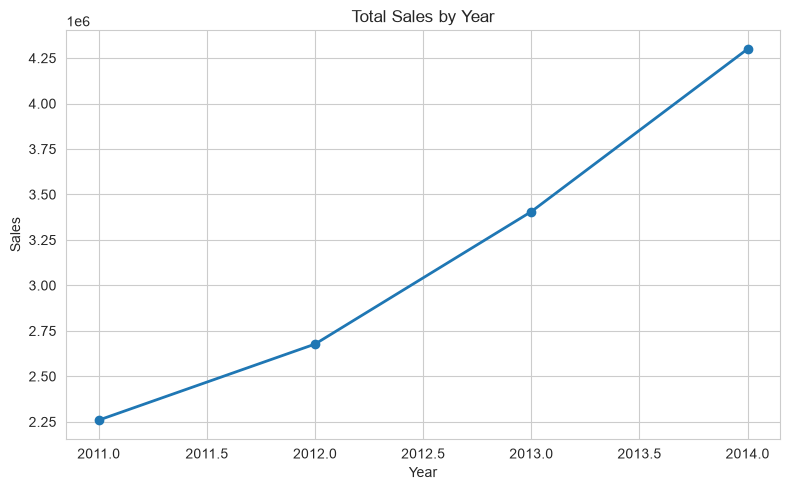

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(sales_by_year.index,
         sales_by_year.values,
         marker="o",
         linewidth=2)

plt.title("Total Sales by Year")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.tight_layout()
# plt.savefig("../figures/sales_trend.png", dpi=300)

plt.show()

# ****Profit Procedure Overtime****

In [9]:
profit_by_year = (df_new.groupby('order_year')['profit'].sum().sort_values(ascending=False))
profit_by_month = (df_new.groupby('order_month')['profit'].sum().sort_values(ascending=False))
profit_by_quarter = (df_new.groupby('quarter')['profit'].sum().sort_values(ascending=False))
profit_by_category = (df_new.groupby('category')['profit'].sum().sort_values(ascending=False))
profit_by_subcategory = (df_new.groupby('sub-category')['profit'].sum().sort_values(ascending=False))

In [10]:
profit_by_year

order_year
2014    504165.97046
2013    406935.23018
2012    307415.27910
2011    248940.81154
Name: profit, dtype: float64

In [11]:
profit_by_month

order_month
11    175449.48412
12    170718.12710
9     170438.18316
10    157269.35838
8     151854.10972
6     147079.41684
5     104509.78428
3      94087.52096
7      78070.09172
1      73535.38454
4      73513.63124
2      70932.19922
Name: profit, dtype: float64

In [12]:
profit_by_quarter

quarter
4    503436.96960
3    400362.38460
2    325102.83236
1    238555.10472
Name: profit, dtype: float64

In [13]:
profit_by_category

category
Technology         663778.73318
Office Supplies    518473.83430
Furniture          285204.72380
Name: profit, dtype: float64

In [14]:
profit_by_subcategory

sub-category
Copiers        258567.54818
Phones         216717.00580
Bookcases      161924.41950
Appliances     141680.58940
Chairs         140396.26750
Accessories    129626.30620
Storage        108461.48980
Binders         72449.84600
Paper           59207.68270
Machines        58867.87300
Art             57953.91090
Furnishings     46967.42550
Envelopes       29601.11630
Supplies        22583.26310
Labels          15010.51200
Fasteners       11525.42410
Tables         -64083.38870
Name: profit, dtype: float64

In [15]:
df_new.groupby('category')['profit_margin'].mean().sort_values(ascending=False)

category
Office Supplies    0.058965
Technology         0.049679
Furniture          0.008593
Name: profit_margin, dtype: float64

In [16]:
df_new['loss_order'].value_counts(normalize=True) * 100

loss_order
No     75.542991
Yes    24.457009
Name: proportion, dtype: float64

In [17]:
df_new.groupby('region')['profit'].sum().sort_values(ascending=False)

region
Central           311403.98164
North             194597.95252
North Asia        165578.42100
South             140355.76618
Central Asia      132480.18700
Oceania           120089.11200
West              108418.44890
East               91522.78000
Africa             88871.63100
EMEA               43897.97100
Caribbean          34571.32104
Southeast Asia     17852.32900
Canada             17817.39000
Name: profit, dtype: float64

In [18]:
df_new.groupby('discount_category')['profit'].mean().sort_values(ascending=False)

discount_category
No Discount    61.039514
Low            46.694431
Medium        -56.190669
High          -98.893015
Name: profit, dtype: float64

In [19]:
df_new.groupby('discount')['profit'].mean().sort_values(ascending=False)

discount
0.070     140.990022
0.002     125.762649
0.100      63.683426
0.000      61.039514
0.150      50.602409
0.170      38.317107
0.200      23.552594
0.250       4.043371
0.270      -4.317213
0.202     -14.518847
0.450     -38.472605
0.470     -42.982420
0.400     -45.246603
0.300     -57.899557
0.370     -78.462191
0.600     -81.732147
0.320     -88.560656
0.500     -97.140158
0.700    -104.339576
0.402    -109.908138
0.350    -116.144693
0.800    -122.203244
0.602    -213.279085
0.550    -315.067200
0.650    -365.997971
0.570    -526.129000
0.450    -551.595750
0.850   -1534.329000
Name: profit, dtype: float64

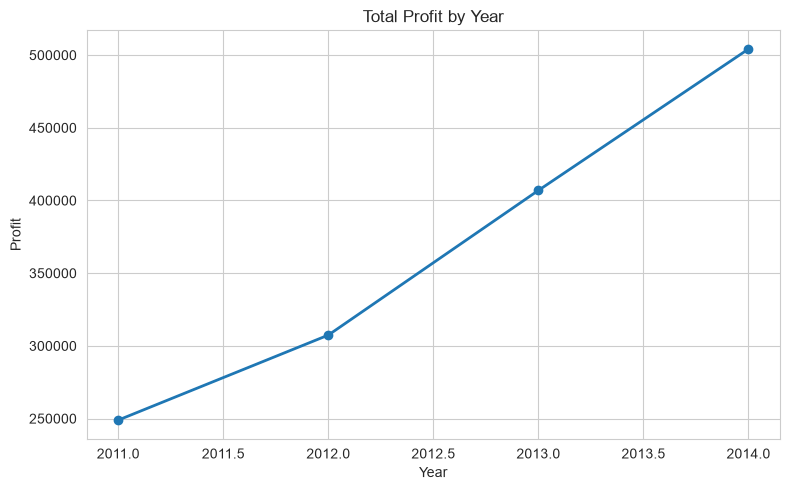

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(profit_by_year.index,
         profit_by_year.values,
         marker="o",
         linewidth=2)

plt.title("Total Profit by Year")
plt.xlabel("Year")
plt.ylabel("Profit")

plt.tight_layout()
# plt.savefig("../figures/profit_trend.png", dpi=300)

plt.show()

# ****Customer Analysis****

In [21]:
df_new.groupby('segment')['profit'].sum().sort_values(ascending=False)

segment
Consumer       749239.78206
Corporate      441208.32866
Home Office    277009.18056
Name: profit, dtype: float64

In [22]:
df.groupby('segment')['order_id'].nunique().sort_values(ascending=False)

segment
Consumer       13104
Corporate       7673
Home Office     4687
Name: order_id, dtype: int64

In [23]:
df_new.groupby('segment')['customer_id'].nunique().sort_values(ascending=False)

segment
Consumer       818
Corporate      476
Home Office    296
Name: customer_id, dtype: int64

In [24]:
df_new.groupby('customer_id')['sales'].sum().mean()

np.float64(7951.25906281761)

In [25]:
df.groupby(['customer_id', 'customer_name'])['sales'].sum().sort_values(ascending=False)[:10]

customer_id  customer_name   
TA-21385     Tom Ashbrook        35668.12080
GT-14710     Greg Tran           34471.89028
TC-20980     Tamara Chand        34218.26900
SM-20320     Sean Miller         31125.29496
BW-11110     Bart Watters        30613.61650
HL-15040     Hunter Lopez        29664.23058
SE-20110     Sanjit Engle        29532.62502
PS-19045     Penelope Sewall     29252.31940
RB-19360     Raymond Buch        29197.63460
ZC-21910     Zuschuss Carroll    28472.81926
Name: sales, dtype: float64

In [26]:
df.groupby(['customer_id', 'customer_name'])['profit'].sum().sort_values(ascending=False)[:10]

customer_id  customer_name
TC-20980     Tamara Chand     8787.47490
RB-19360     Raymond Buch     8523.95150
SC-20095     Sanjit Chand     8106.21790
BE-11335     Bill Eplett      7790.69630
HL-15040     Hunter Lopez     7657.50178
AB-10105     Adrian Barton    6912.61450
SP-20920     Susan Pistek     6649.62626
HM-14860     Harry Marie      6544.88640
TA-21385     Tom Ashbrook     6274.98910
SE-20110     Sanjit Engle     5863.62392
Name: profit, dtype: float64

In [27]:
df.groupby('customer_id')['order_id'].nunique().describe()

count    1590.000000
mean       16.196855
std        10.619199
min         1.000000
25%         6.000000
50%        14.000000
75%        26.000000
max        41.000000
Name: order_id, dtype: float64

### ****pareto Analyze (80/20)****

In [28]:
customer_sales = (df_new.groupby('customer_id')['sales'].sum().sort_values(ascending=False))

customer_sales = customer_sales.reset_index()
customer_sales['sales_pct'] = (customer_sales['sales'] /customer_sales['sales'].sum())

customer_sales['cum_sales_pct'] = (customer_sales['sales_pct'].cumsum())
customer_sales['customer_pct'] = ((customer_sales.index + 1) /len(customer_sales))

In [29]:
customer_sales[customer_sales['cum_sales_pct'] <= 0.80]

,customer_id,sales,sales_pct,cum_sales_pct,customer_pct
0,TA-21385,35668.12080,0.002821,0.002821,0.000629
1,GT-14710,34471.89028,0.002727,0.005548,0.001258
2,TC-20980,34218.26900,0.002707,0.008255,0.001887
3,SM-20320,31125.29496,0.002462,0.010717,0.002516
4,BW-11110,30613.61650,0.002421,0.013138,0.003145
...,...,...,...,...,...
671,NC-18415,9255.79400,0.000732,0.797022,0.422642
672,LM-17065,9249.38300,0.000732,0.797754,0.423270
673,DK-13225,9246.46860,0.000731,0.798485,0.423899
674,CS-12355,9240.89700,0.000731,0.799216,0.424528


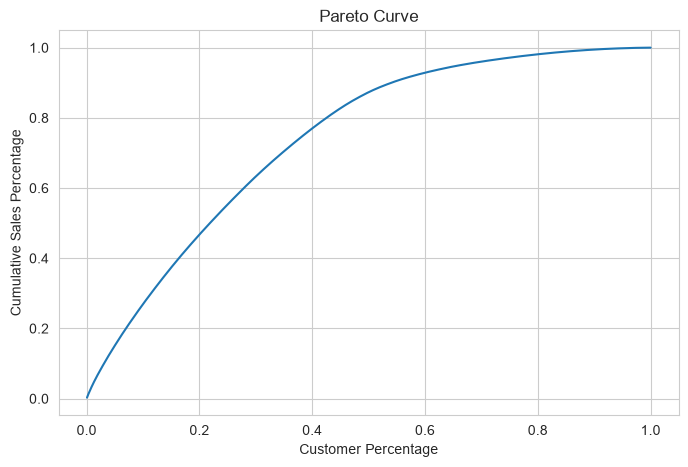

In [30]:
plt.figure(figsize=(8,5))

plt.plot(
    customer_sales['customer_pct'],
    customer_sales['cum_sales_pct']
)

plt.xlabel('Customer Percentage')
plt.ylabel('Cumulative Sales Percentage')
plt.title('Pareto Curve')

plt.grid(True)
plt.show()

# ****Product Analysis****

In [31]:
sales_by_category = (df_new.groupby('category')['sales'].sum().sort_values(ascending=False))
sales_by_category

category
Technology         4.744557e+06
Furniture          4.110874e+06
Office Supplies    3.787070e+06
Name: sales, dtype: float64

In [32]:
sales_by_subcategory = (df_new.groupby('sub-category')['sales'].sum().sort_values(ascending=False))
sales_by_subcategory

sub-category
Phones         1.706824e+06
Copiers        1.509436e+06
Chairs         1.501682e+06
Bookcases      1.466572e+06
Storage        1.127086e+06
Appliances     1.011064e+06
Machines       7.790601e+05
Tables         7.570419e+05
Accessories    7.492370e+05
Binders        4.619115e+05
Furnishings    3.855783e+05
Art            3.720920e+05
Paper          2.442917e+05
Supplies       2.430742e+05
Envelopes      1.709043e+05
Fasteners      8.324232e+04
Labels         7.340403e+04
Name: sales, dtype: float64

In [33]:
quantity_by_category = (df_new.groupby('category')['quantity'].sum().sort_values(ascending=False))
quantity_by_category

category
Office Supplies    108182
Technology          35176
Furniture           34954
Name: quantity, dtype: int64

In [34]:
quantity_by_subcategory = (df_new.groupby('sub-category')['quantity'].sum().sort_values(ascending=False))
quantity_by_subcategory

sub-category
Binders        21429
Storage        16917
Art            16301
Paper          12822
Chairs         12336
Phones         11870
Furnishings    11225
Accessories    10946
Labels          9322
Supplies        8543
Fasteners       8390
Envelopes       8380
Bookcases       8310
Copiers         7454
Appliances      6078
Machines        4906
Tables          3083
Name: quantity, dtype: int64

In [35]:
avg_sales_category = (df_new.groupby('category')['sales'].mean().sort_values(ascending=False))
avg_sales_category

category
Technology         467.858939
Furniture          416.248905
Office Supplies    121.097120
Name: sales, dtype: float64

In [36]:
avg_profit_category = (df_new.groupby('category')['profit'].mean().sort_values(ascending=False))
avg_profit_category

category
Technology         65.454958
Furniture          28.878567
Office Supplies    16.578961
Name: profit, dtype: float64

In [37]:
top_sales_products = (df_new.groupby('product_name')['sales'].sum().sort_values(ascending=False))[:10]
top_sales_products

product_name
Apple Smart Phone, Full Size                                86935.7786
Cisco Smart Phone, Full Size                                76441.5306
Motorola Smart Phone, Full Size                             73156.3030
Nokia Smart Phone, Full Size                                71904.5555
Canon imageCLASS 2200 Advanced Copier                       61599.8240
Hon Executive Leather Armchair, Adjustable                  58193.4841
Office Star Executive Leather Armchair, Adjustable          50661.6840
Harbour Creations Executive Leather Armchair, Adjustable    50121.5160
Samsung Smart Phone, Cordless                               48653.4600
Nokia Smart Phone, with Caller ID                           47877.7857
Name: sales, dtype: float64

In [38]:
top_profit_products = (df_new.groupby('product_name')['profit'].sum().sort_values(ascending=False))[:10]
top_profit_products

product_name
Canon imageCLASS 2200 Advanced Copier                       25199.9280
Cisco Smart Phone, Full Size                                17238.5206
Motorola Smart Phone, Full Size                             17027.1130
Hoover Stove, Red                                           11807.9690
Sauder Classic Bookcase, Traditional                        10672.0730
Harbour Creations Executive Leather Armchair, Adjustable    10427.3260
Nokia Smart Phone, Full Size                                 9938.1955
Cisco Smart Phone, with Caller ID                            9786.6408
Nokia Smart Phone, with Caller ID                            9465.3257
Belkin Router, USB                                           8955.0180
Name: profit, dtype: float64

In [39]:
loss_products = (df_new.groupby('product_name')['profit'].sum().sort_values())[:10]
loss_products

product_name
Cubify CubeX 3D Printer Double Head Print                  -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                  -4589.9730
Motorola Smart Phone, Cordless                             -4447.0380
Cubify CubeX 3D Printer Triple Head Print                  -3839.9904
Bevis Round Table, Adjustable Height                       -3649.8940
Bevis Computer Table, Fully Assembled                      -3509.5638
Rogers Lockers, Blue                                       -2893.4908
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases   -2876.1156
Bevis Wood Table, with Bottom Storage                      -2782.5880
Lesro Training Table, Rectangular                          -2581.2834
Name: profit, dtype: float64

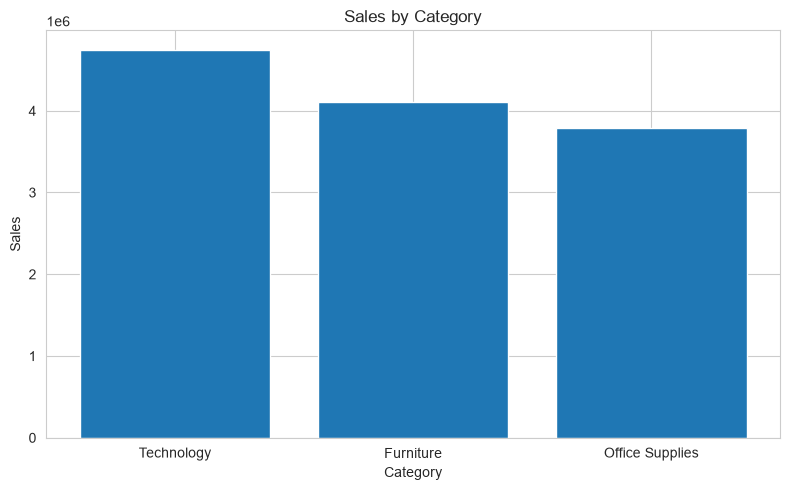

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(sales_by_category.index,
        sales_by_category.values)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.tight_layout()
# plt.savefig("../figures/sales_by_category.png", dpi=300)

plt.show()

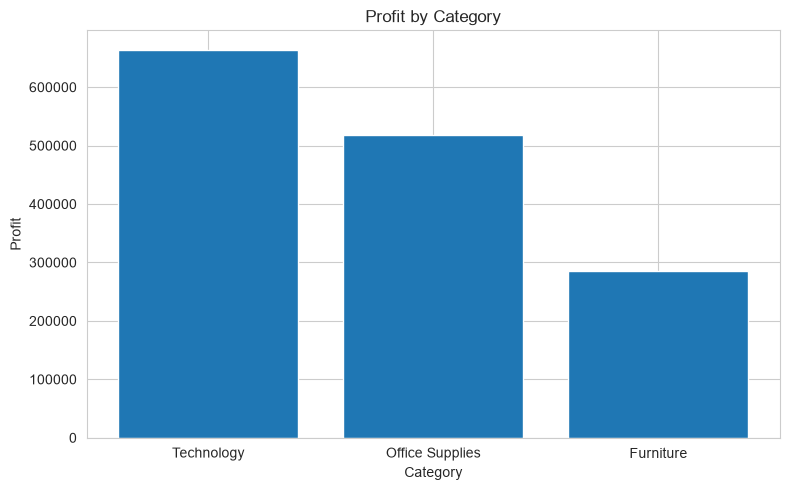

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(profit_by_category.index,
        profit_by_category.values)

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.tight_layout()
# plt.savefig("../figures/profit_by_category.png", dpi=300)

plt.show()

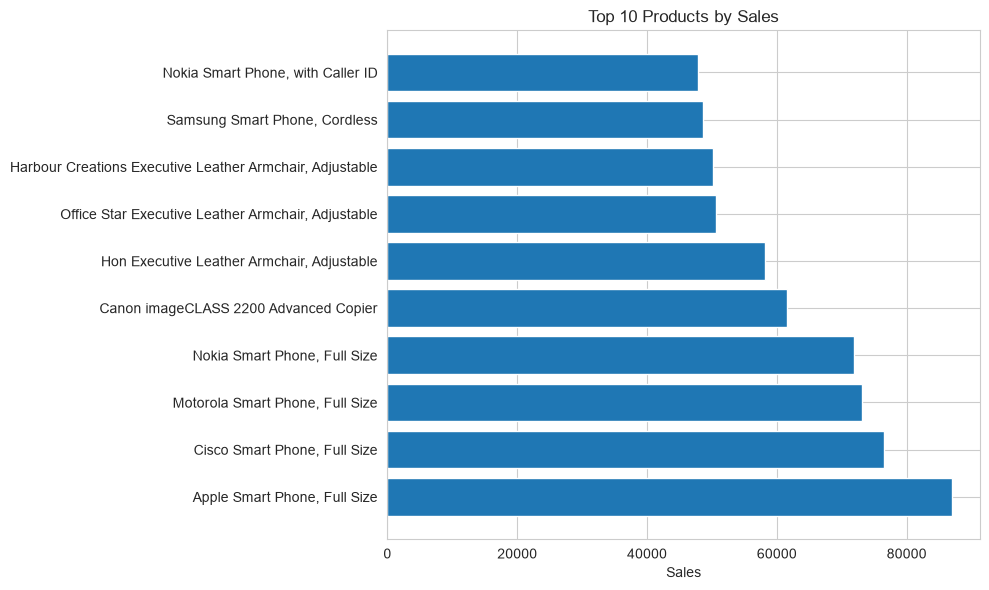

In [ ]:
plt.figure(figsize=(10,6))
plt.barh(top_sales_products.index,
         top_sales_products.values)

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")

plt.tight_layout()
# plt.savefig("../figures/top_products.png", dpi=300)

plt.show()

# ****Regional Analysis****

In [43]:
sales_by_region = (
    df_new.groupby('region')['sales']
    .sum()
    .sort_values(ascending=False)
)

sales_by_region

region
Central           2.822303e+06
South             1.600907e+06
North             1.248166e+06
Oceania           1.100185e+06
Southeast Asia    8.844232e+05
North Asia        8.483098e+05
EMEA              8.061613e+05
Africa            7.837732e+05
Central Asia      7.528266e+05
West              7.254578e+05
East              6.787812e+05
Caribbean         3.242809e+05
Canada            6.692817e+04
Name: sales, dtype: float64

In [44]:
sales_by_market = (
    df_new.groupby('market')['sales']
    .sum()
    .sort_values(ascending=False)
)

sales_by_market

market
APAC      3.585744e+06
EU        2.938089e+06
US        2.297201e+06
LATAM     2.164605e+06
EMEA      8.061613e+05
Africa    7.837732e+05
Canada    6.692817e+04
Name: sales, dtype: float64

In [45]:
sales_by_country = (df_new.groupby('country')['sales'].sum().sort_values(ascending=False).head(10))
sales_by_country

country
United States     2.297201e+06
Australia         9.252359e+05
France            8.589311e+05
China             7.005620e+05
Germany           6.288400e+05
Mexico            6.225906e+05
India             5.896501e+05
United Kingdom    5.285763e+05
Indonesia         4.048875e+05
Brazil            3.611064e+05
Name: sales, dtype: float64

In [46]:
profit_by_country = (df_new.groupby('country')['profit'].sum().sort_values(ascending=False))[:10]
profit_by_country

country
United States     286397.02170
China             150683.08500
India             129071.83500
United Kingdom    111900.15000
France            109029.00300
Germany           107322.82050
Australia         103907.43300
Mexico            102818.09752
Spain              54390.12000
El Salvador        42023.24320
Name: profit, dtype: float64

In [47]:
loss_country = (df_new.groupby('country')['profit'].sum().sort_values())[:10]
loss_country

country
Turkey        -98447.23200
Nigeria       -80750.71800
Netherlands   -41070.07500
Honduras      -29482.37140
Pakistan      -22446.64800
Argentina     -18693.79672
Panama        -17723.45248
Sweden        -17519.36700
Philippines   -16128.22500
South Korea   -12792.83100
Name: profit, dtype: float64

In [48]:
sales_by_city = (df_new.groupby('city')['sales'].sum().sort_values(ascending=False))[:10]
sales_by_city

city
New York City    256368.16100
Los Angeles      175851.34100
Manila           120886.94850
Seattle          119540.74200
San Francisco    112669.09200
Philadelphia     109077.01300
Sydney           101945.51700
Jakarta           94321.32420
London            86945.80500
Mexico City       85728.55176
Name: sales, dtype: float64

In [49]:
profit_by_city = (df_new.groupby('city')['profit'].sum().sort_values(ascending=False))[:10]
profit_by_city

city
New York City    62036.98370
Los Angeles      30440.75790
Seattle          29156.09670
Managua          17853.71804
San Francisco    17507.38540
London           17378.71500
Sydney           16002.80700
Vienna           15660.84000
San Salvador     15036.51040
Mexico City      13342.29176
Name: profit, dtype: float64

In [50]:
profit_margin_market = (df_new.groupby('market')['profit_margin'].mean().sort_values(ascending=False))
profit_margin_market

market
Canada    0.247500
US        0.120314
EU        0.110207
APAC      0.069520
LATAM     0.061923
EMEA     -0.141231
Africa   -0.143648
Name: profit_margin, dtype: float64

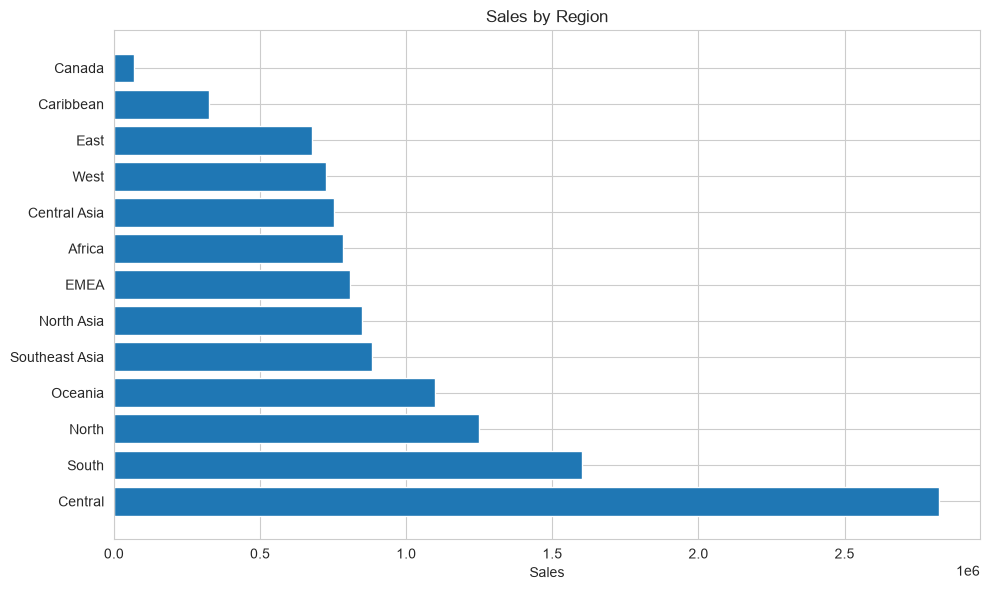

In [ ]:
plt.figure(figsize=(10,6))
plt.barh(sales_by_region.index,
         sales_by_region.values)

plt.title("Sales by Region")
plt.xlabel("Sales")

plt.tight_layout()
# plt.savefig("../figures/sales_by_region.png", dpi=300)

plt.show()

# ****shipping analysis****

In [52]:
df_new.groupby('ship_mode')['sales'].sum().sort_values(ascending=False)

ship_mode
Standard Class    7.578652e+06
Second Class      2.565672e+06
First Class       1.830976e+06
Same Day          6.672020e+05
Name: sales, dtype: float64

In [53]:
df_new.groupby('ship_mode')['profit'].sum().sort_values(ascending=False)

ship_mode
Standard Class    890596.02120
Second Class      292583.52708
First Class       208104.67520
Same Day           76173.06780
Name: profit, dtype: float64

In [54]:
df_new.groupby('ship_mode')['shipping_days'].mean()

ship_mode
First Class       2.181746
Same Day          0.037394
Second Class      3.230187
Standard Class    4.998018
Name: shipping_days, dtype: float64

In [55]:
df_new.groupby('ship_mode')['order_id'].nunique().sort_values(ascending=False)

ship_mode
Standard Class    15154
Second Class       5119
First Class        3821
Same Day           1347
Name: order_id, dtype: int64

In [56]:
df_new.groupby('ship_mode')['profit'].mean().sort_values(ascending=False)

ship_mode
Standard Class    28.938945
Second Class      28.381368
Same Day          28.201802
First Class       27.728804
Name: profit, dtype: float64